In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

True
1
NVIDIA GeForce GTX 1650


In [3]:
device = torch.device('cuda')

In [4]:
words = open("names.txt", "r").read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [5]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0

itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [6]:
block_size = 3 #  context lengthL how many characters do we take to predict the next one
X, Y = [], []
for w in words:
    
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix= stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix] # crop and append
        
X = torch.tensor(X, device=device)
Y = torch.tensor(Y, device=device)

In [7]:
# build the dataset

def build_dataset(words):
    block_size = 3 #  context lengthL how many characters do we take to predict the next one
    X, Y = [], []
    for w in words:
        
        # print(w)
        context = [0] * block_size
        for ch in w + '.':
            ix= stoi[ch]
            X.append(context)
            Y.append(ix)
            # print(''.join(itos[i] for i in context), '---->', itos[ix])
            context = context[1:] + [ix] # crop and append
            
    X = torch.tensor(X, device=device)
    Y = torch.tensor(Y, device=device)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [8]:
Xtr.shape, Xtr.dtype, Ytr.shape, Ytr.dtype

(torch.Size([182625, 3]), torch.int64, torch.Size([182625]), torch.int64)

In [9]:
C = torch.randn((27,2), device=device)

In [10]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [11]:
w1 = torch.randn(6,100, device=device)
b1 = torch.randn(100, device=device)

In [12]:
h = torch.tanh(emb.view(-1,6) @ w1 + b1)

In [13]:
h.shape

torch.Size([228146, 100])

In [14]:
w2 = torch.randn(100,27, device=device)
b2 = torch.randn(27, device=device)

In [15]:
logits = h @ w2 + b2
logits.shape

torch.Size([228146, 27])

In [16]:
counts = logits.exp()

In [17]:
prob = counts / counts.sum(1, keepdim=True)

In [18]:
prob.shape

torch.Size([228146, 27])

In [19]:
## summarized ##

In [20]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [65]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

g = torch.Generator(device=device).manual_seed(2147483647)
C = torch.randn((27,10), generator=g, device=device)
w1 = torch.randn((30,200), generator=g, device=device)
b1 = torch.randn(200, generator=g, device=device)
w2 = torch.randn((200,27), generator=g, device=device)
b2 = torch.randn(27, generator=g, device=device)

In [66]:
parameters = [C, w1, b1, w2, b2]

for p in parameters:
    p.requires_grad = True

In [67]:
sum(p.nelement() for p in parameters)

11897

In [48]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [68]:
lri = []
lossi = []
stepi = []

In [69]:
for i in range(200000):
    # mininbactch construct
    ix = torch.randint(0, Xtr.shape[0], (32,))
    
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,30) @ w1 + b1)
    logits = h @ w2 + b2
    loss = F.cross_entropy(logits,Ytr[ix])
    # print(loss.item())


    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
        
    stepi.append(i)
    lossi.append(loss.log10().item())
        
print(loss.item())

1.9447203874588013


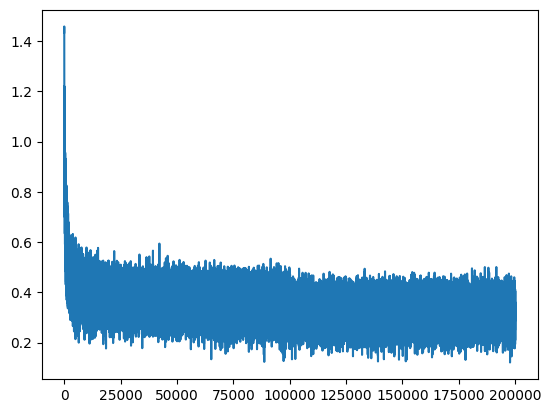

In [70]:
plt.plot(stepi, lossi)

In [71]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,30) @ w1 + b1)
logits = h @ w2 + b2
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1128, device='cuda:0', grad_fn=<NllLossBackward0>)

In [72]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,30) @ w1 + b1)
logits = h @ w2 + b2
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1558, device='cuda:0', grad_fn=<NllLossBackward0>)

In [ ]:
# training split, dev/validation split, test split
# 80%, 10%, 10%

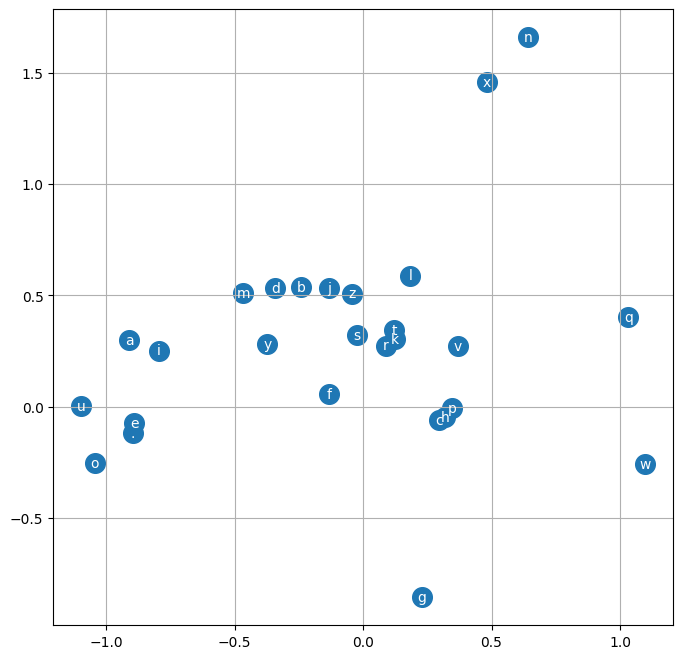

In [73]:
C_cpu = C.detach().cpu()

plt.figure(figsize=(8,8))
plt.scatter(C_cpu[:,0].data, C_cpu[:,1].data, s=200)
for i in range(C_cpu.shape[0]):
    plt.text(C_cpu[i,0].item(), C_cpu[i,1].item(), itos[i], ha='center', va='center', color='white')
    
plt.grid('minor')

In [75]:
g = torch.Generator(device=device).manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size

    while True:
        context_tensor = torch.tensor([context], device=device)

        emb = C[context_tensor]
        h = torch.tanh(emb.view(1, -1) @ w1 + b1)
        logits = h @ w2 + b2
        probs = F.softmax(logits, dim=1)

        ix = torch.multinomial(
            probs,
            num_samples=1,
            generator=g
        ).item()

        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

bree.
sah.
zemadricelijahnardr.
ley.
jeidynousrah.
emi.
chratti.
gewfylissin.
canti.
elloni.
absontaly.
ken.
jidyn.
zazhraan.
jurlana.
dorge.
davel.
thi.
brookison.
katerick.
